In [22]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


VF = -0.00041674445961907433
WF = -0.32576593396575665


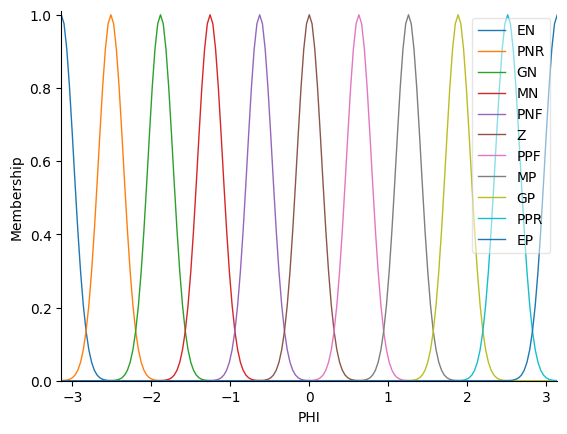

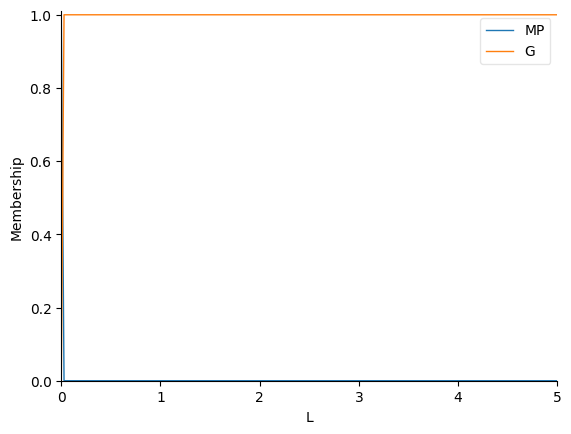

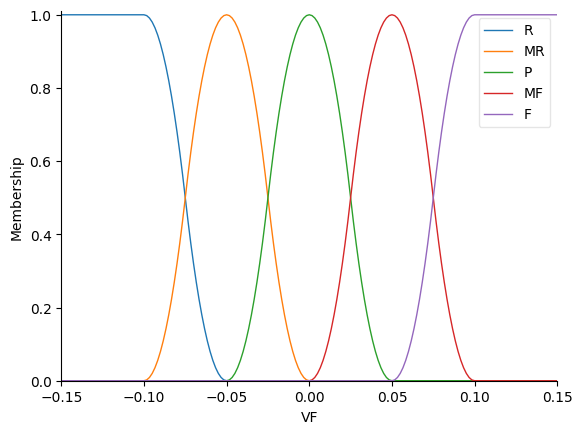

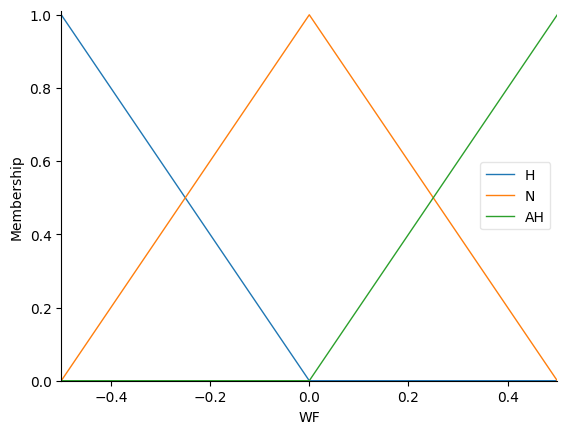

In [5]:

# ===== Variáveis (todas com 181 pontos, como no MATLAB) =====
PHI = ctrl.Antecedent(np.linspace(-np.pi, np.pi, 181), 'PHI')
L   = ctrl.Antecedent(np.linspace(0, 5, 181), 'L')

VF  = ctrl.Consequent(np.linspace(-0.15, 0.15, 181), 'VF')
WF  = ctrl.Consequent(np.linspace(-0.5, 0.5, 181), 'WF')

## ===== Parâmetros Variáveis =======
Z_dp = 0.1571
PFF_dp = 0.1571
MP_dp = 0.1571
PFF_m = 0.6283
MP_m =  1.2566
## ==================================

# ===== PHI (Gauss MF) - mantido conforme skfuzzy (mean, sigma) =====
PHI['EN']  = fuzz.gaussmf(PHI.universe, -3.1416, Z_dp)
PHI['PNR'] = fuzz.gaussmf(PHI.universe, PFF_m - np.pi, PFF_dp)
PHI['GN']  = fuzz.gaussmf(PHI.universe, MP_m - np.pi,   MP_dp)
PHI['MN']  = fuzz.gaussmf(PHI.universe, -MP_m,     MP_dp)
PHI['PNF'] = fuzz.gaussmf(PHI.universe, -PFF_m,   PFF_dp)
PHI['Z']   = fuzz.gaussmf(PHI.universe, 0,          Z_dp)
PHI['PPF'] = fuzz.gaussmf(PHI.universe, PFF_m,    PFF_dp)
PHI['MP']  = fuzz.gaussmf(PHI.universe, MP_m,      MP_dp)
PHI['GP']  = fuzz.gaussmf(PHI.universe, np.pi - MP_m,    MP_dp)
PHI['PPR'] = fuzz.gaussmf(PHI.universe, np.pi - PFF_m,   PFF_dp)
PHI['EP']  = fuzz.gaussmf(PHI.universe, 3.1416,  Z_dp)

# ===== L (mantido) =====
L['MP'] = fuzz.zmf(L.universe, 0.01, 0.02)  # linzmf ≈ zmf
L['G']  = fuzz.smf(L.universe, 0.01, 0.02)  # linsmf ≈ smf

# ===== VF (SAÍDA) =====
# Correção pedida: apenas as "pi das bordas" por trapezoidais (R e F trocadas),
# mantendo as demais como pimf.
VF['R']  = fuzz.pimf(VF.universe, -0.151, -0.15, -0.1, -0.05)            # borda esquerda -> trap
VF['MR'] = fuzz.pimf(VF.universe, -0.1, -0.05, -0.05, 0)               # mantém pimf
VF['P']  = fuzz.pimf(VF.universe, -0.05, 0, 0, 0.05)                   # mantém pimf
VF['MF'] = fuzz.pimf(VF.universe, 0, 0.05, 0.05, 0.1)                  # mantém pimf
VF['F']  = fuzz.pimf(VF.universe, 0.05, 0.1, 0.15, 0.151)          # borda direita -> trap
fuzz.pimf(VF.universe, 0.05, 0.1, 0.15, 0.151)  
# ===== WF (SAÍDA) - manter zmf / trimf / smf conforme .fis =====
WF['H'] = fuzz.trimf(WF.universe, [-0.5, -0.5, 0]) # linzmf ≈ zmf 
WF['N'] = fuzz.trimf(WF.universe, [-0.5, 0, 0.5]) 
WF['AH'] = fuzz.trimf(WF.universe, [0, 0.5, 0.5]) # linsmf ≈ smf

# ===== Regras (REVERTIDAS para a versão inicial que você tinha no Python) =====
# Usei a tradução direta dos nomes conforme seu primeiro código em Python.
rule1  = ctrl.Rule(L['MP'], (VF['P'], WF['N']))                # don't care PHI
rule2  = ctrl.Rule(PHI['EN']  & L['G'], (VF['R'],  WF['N']))
rule3  = ctrl.Rule(PHI['PNR'] & L['G'], (VF['MR'], WF['AH']))
rule4  = ctrl.Rule(PHI['GN']  & L['G'], (VF['P'],  WF['AH']))
rule5  = ctrl.Rule(PHI['MN']  & L['G'], (VF['P'],  WF['H']))
rule6  = ctrl.Rule(PHI['PNF'] & L['G'], (VF['MF'], WF['H']))
rule7  = ctrl.Rule(PHI['Z']   & L['G'], (VF['F'],  WF['N']))
rule8  = ctrl.Rule(PHI['PPF'] & L['G'], (VF['MF'], WF['AH']))
rule9  = ctrl.Rule(PHI['MP']  & L['G'], (VF['P'],  WF['AH']))
rule10 = ctrl.Rule(PHI['GP']  & L['G'], (VF['P'],  WF['H']))
rule11 = ctrl.Rule(PHI['PPR'] & L['G'], (VF['MR'], WF['H']))
rule12 = ctrl.Rule(PHI['EP']  & L['G'], (VF['R'],  WF['N']))

# ==============================
# Controlador
# ==============================
VF.defuzzify_method = 'centroid'
WF.defuzzify_method = 'centroid'

system = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11, rule12
])
sim = ctrl.ControlSystemSimulation(system)

# Exemplo de uso: entrada (-1, 2)
sim.input['PHI'] = 2.0
sim.input['L']   = 2.0
sim.compute()

# Saída
print("VF =", sim.output['VF'])
print("WF =", sim.output['WF'])
PHI.view()
L.view()
VF.view()
WF.view()

sim.output (API) -> VF = 0.00876910171994967  WF = -0.3083166868152745
diagnóstico -> max agreg VF: 0.26592253820633877 max agreg WF: 0.26592253820633877
defuzz manual -> VF: 0.008759220686303576  WF: -0.30832517613178323


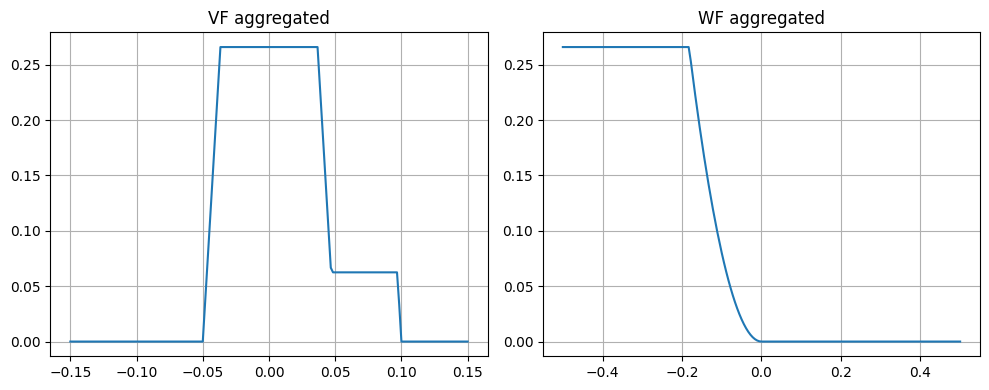

In [24]:
# ===== Variáveis (mesma estrutura)
PHI = ctrl.Antecedent(np.linspace(-np.pi, np.pi, 181), 'PHI')
L   = ctrl.Antecedent(np.linspace(0, 5, 181), 'L')

# Aumentei resolução das saídas para reduzir erros de centroid discretizado
VF  = ctrl.Consequent(np.linspace(-0.15, 0.15, 181), 'VF')   # 1001 pontos
WF  = ctrl.Consequent(np.linspace(-0.5, 0.5, 181), 'WF')

## =====Parametros Variáveis=======
Z_dp = 0.1571
PFF_dp = 0.1571
MP_dp = 0.1571
PFF_m = 0.6283
MP_m =  1.2566
##================================

# ===== PHI (Gauss MF) - mantido conforme sua preferência (skfuzzy: mean, sigma) =====
PHI['EN']  = fuzz.gaussmf(PHI.universe, -3.1416, Z_dp)
PHI['PNR'] = fuzz.gaussmf(PHI.universe, PFF_m - np.pi, PFF_dp)
PHI['GN']  = fuzz.gaussmf(PHI.universe, MP_m - np.pi,   MP_dp)
PHI['MN']  = fuzz.gaussmf(PHI.universe, -MP_m,     MP_dp)
PHI['PNF'] = fuzz.gaussmf(PHI.universe, -PFF_m,   PFF_dp)
PHI['Z']   = fuzz.gaussmf(PHI.universe, 0,          Z_dp)
PHI['PPF'] = fuzz.gaussmf(PHI.universe, PFF_m,    PFF_dp)
PHI['MP']  = fuzz.gaussmf(PHI.universe, MP_m,      MP_dp)
PHI['GP']  = fuzz.gaussmf(PHI.universe, np.pi - MP_m,    MP_dp)
PHI['PPR'] = fuzz.gaussmf(PHI.universe, np.pi - PFF_m,   PFF_dp)
PHI['EP']  = fuzz.gaussmf(PHI.universe, 3.1416,  Z_dp)

# ===== L (mantido) =====
L['MP'] = fuzz.zmf(L.universe, 0.01, 0.02)  # linzmf ≈ zmf
L['G']  = fuzz.smf(L.universe, 0.01, 0.02)  # linsmf ≈ smf

# ===== VF (SAÍDA) - usar trapmf no lugar de pimf para evitar platôs degenerados =====
VF['R']  = fuzz.trapmf(VF.universe, [-0.15, -0.15, -0.1, -0.05])
VF['MR'] = fuzz.trapmf(VF.universe, [-0.1, -0.05, -0.05, 0])
VF['P']  = fuzz.trapmf(VF.universe, [-0.05, 0, 0, 0.05])
VF['MF'] = fuzz.trapmf(VF.universe, [0, 0.05, 0.05, 0.1])
VF['F']  = fuzz.trapmf(VF.universe, [0.05, 0.1, 0.15, 0.15])

# ===== WF (SAÍDA) - manter zmf/trimf/smf conforme .fis =====
WF['H']  = fuzz.zmf(WF.universe, -0.5, 0)           # linzmf ≈ zmf
WF['N']  = fuzz.trimf(WF.universe, [-0.5, 0, 0.5])
WF['AH'] = fuzz.smf(WF.universe, 0, 0.5)            # linsmf ≈ smf

# ===== Regras: tradução correta do .fis (1-based + 0 = don't care) =====
rule1  = ctrl.Rule(L['MP'], (VF['P'], WF['N']))                # don't care PHI
rule2  = ctrl.Rule(PHI['EN']  & L['G'], (VF['R'],  WF['N']))
rule3  = ctrl.Rule(PHI['PNR'] & L['G'], (VF['MR'], WF['AH']))
rule4  = ctrl.Rule(PHI['GN']  & L['G'], (VF['P'],  WF['AH']))
rule5  = ctrl.Rule(PHI['MN']  & L['G'], (VF['P'],  WF['H']))
rule6  = ctrl.Rule(PHI['PNF'] & L['G'], (VF['MF'], WF['H']))
rule7  = ctrl.Rule(PHI['Z']   & L['G'], (VF['F'],  WF['N']))
rule8  = ctrl.Rule(PHI['PPF'] & L['G'], (VF['MF'], WF['AH']))
rule9  = ctrl.Rule(PHI['MP']  & L['G'], (VF['P'],  WF['AH']))
rule10 = ctrl.Rule(PHI['GP']  & L['G'], (VF['P'],  WF['H']))
rule11 = ctrl.Rule(PHI['PPR'] & L['G'], (VF['MR'], WF['H']))
rule12 = ctrl.Rule(PHI['EP']  & L['G'], (VF['R'],  WF['N']))

# ==============================
# Controlador
# ==============================
VF.defuzzify_method = 'centroid'
WF.defuzzify_method = 'centroid'

system = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11, rule12
])
sim = ctrl.ControlSystemSimulation(system)

# Entrada de teste
sim.input['PHI'] = -1.0
sim.input['L']   = 2.0
sim.compute()

# Saída do controlador (API)
print("sim.output (API) -> VF =", sim.output['VF'], " WF =", sim.output['WF'])

# Diagnóstico adicional: reconstruir agregados manualmente (implicação=min, agregação=max)
# para verificar suporte e centroid calculado diretamente.
# Recuperar pertinências de entrada:
phi_val = -1.0
l_val = 2.0
phi_memb = {name: fuzz.interp_membership(PHI.universe, PHI[name].mf, phi_val) for name in PHI.terms}
l_memb   = {name: fuzz.interp_membership(L.universe, L[name].mf, l_val) for name in L.terms}

# Lista de regras como tupla (phi_term_or_none, l_term, vf_out_name, wf_out_name)
rule_defs = [
    (None, 'MP', 'P', 'N'),   # don't care PHI -> None
    ('EN','G','R','N'),
    ('PNR','G','MR','AH'),
    ('GN','G','P','AH'),
    ('MN','G','P','H'),
    ('PNF','G','MF','H'),
    ('Z','G','F','N'),
    ('PPF','G','MF','AH'),
    ('MP','G','P','AH'),
    ('GP','G','P','H'),
    ('PPR','G','MR','H'),
    ('EP','G','R','N'),
]

# calcular forças
rule_strengths = []
for rd in rule_defs:
    phi_term, l_term, vf_name, wf_name = rd
    a_phi = 1.0 if phi_term is None else phi_memb[phi_term]
    a_l = l_memb[l_term]
    strength = np.fmin(a_phi, a_l)
    rule_strengths.append((rd, float(strength)))

# agregação manual
vf_agg = np.zeros_like(VF.universe)
wf_agg = np.zeros_like(WF.universe)
for (rd, s) in rule_strengths:
    if s <= 0: continue
    vf_name = rd[2]
    wf_name = rd[3]
    vf_m = VF[vf_name].mf
    wf_m = WF[wf_name].mf
    vf_clipped = np.fmin(s, vf_m)
    wf_clipped = np.fmin(s, wf_m)
    vf_agg = np.fmax(vf_agg, vf_clipped)
    wf_agg = np.fmax(wf_agg, wf_clipped)

print("diagnóstico -> max agreg VF:", vf_agg.max(), "max agreg WF:", wf_agg.max())

# centroid manual (discretizado)
if vf_agg.max() > 0:
    vf_def_manual = fuzz.defuzz(VF.universe, vf_agg, 'centroid')
else:
    vf_def_manual = np.nan

if wf_agg.max() > 0:
    wf_def_manual = fuzz.defuzz(WF.universe, wf_agg, 'centroid')
else:
    wf_def_manual = np.nan

print("defuzz manual -> VF:", vf_def_manual, " WF:", wf_def_manual)

# plot para inspecionar (opcional)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(VF.universe, vf_agg)
plt.title('VF aggregated')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(WF.universe, wf_agg)
plt.title('WF aggregated')
plt.grid(True)
plt.tight_layout()
plt.show()


--- Resultado da Simulação (em formato de vetor) ---
[-0.04980247 -0.3331048 ]

--- Executando novamente para gerar os gráficos ---
--- Exibindo Gráficos ---


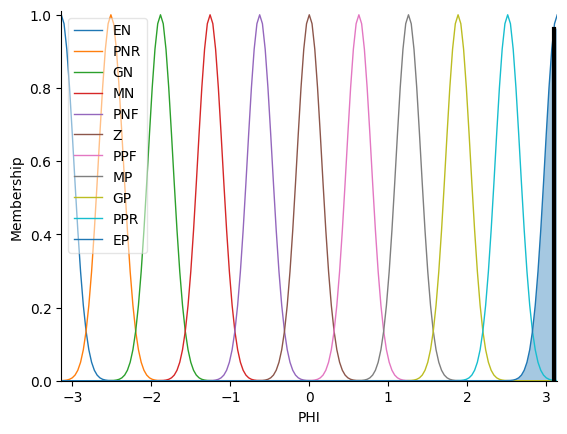

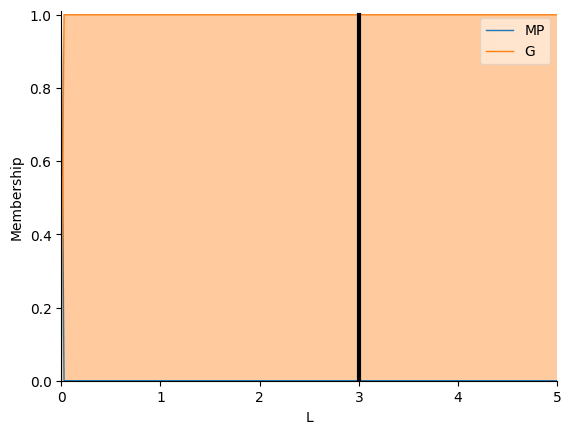

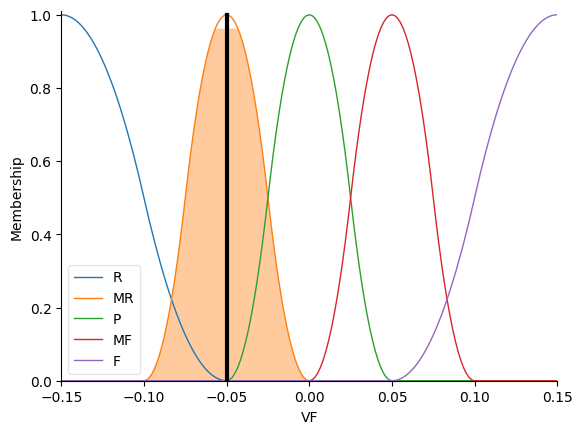

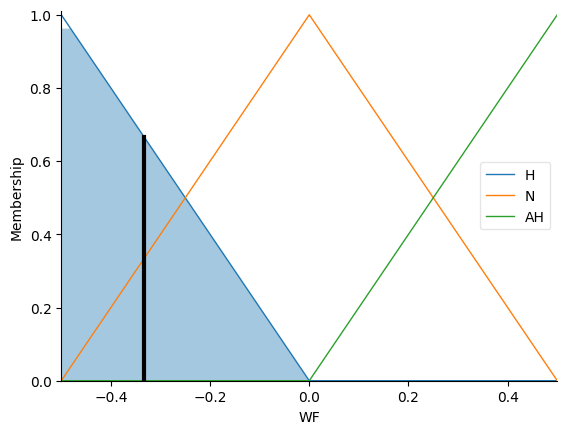

In [24]:
def simular_controlador_fuzzy(
    parametros_vetor, 
    phi_input, 
    l_input, 
    plotar_graficos=False):
    """
    Cria e simula um controlador fuzzy, recebendo os parâmetros
    variáveis como um vetor e retornando as saídas como um vetor.

    Args:
        parametros_vetor (list or np.array): Vetor com os 5 parâmetros variáveis na seguinte ordem:
                                             [z_dp, pff_dp, mp_dp, pff_m, mp_m]
        phi_input (float): Valor de entrada para a variável PHI.
        l_input (float): Valor de entrada para a variável L.
        plotar_graficos (bool): Se True, exibe os gráficos das variáveis.

    Returns:
        np.array: Um array NumPy contendo as saídas [VF, WF].
    """
    
    # 1. Desempacota o vetor de parâmetros
    try:
        z_dp, pff_dp, mp_dp, pff_m, mp_m = parametros_vetor
    except ValueError:
        raise ValueError(f"O vetor de parâmetros deve conter 5 elementos. Recebido: {len(parametros_vetor)}")

    # 2. Define as variáveis do universo fuzzy
    PHI = ctrl.Antecedent(np.linspace(-np.pi, np.pi, 181), 'PHI')
    L   = ctrl.Antecedent(np.linspace(0, 5, 181), 'L')
    VF  = ctrl.Consequent(np.linspace(-0.15, 0.15, 181), 'VF')
    WF  = ctrl.Consequent(np.linspace(-0.5, 0.5, 181), 'WF')

    # 3. Cria as funções de pertinência com os parâmetros
    PHI['EN']  = fuzz.gaussmf(PHI.universe, -np.pi, z_dp)
    PHI['PNR'] = fuzz.gaussmf(PHI.universe, pff_m - np.pi, pff_dp)
    PHI['GN']  = fuzz.gaussmf(PHI.universe, mp_m - np.pi, mp_dp)
    PHI['MN']  = fuzz.gaussmf(PHI.universe, -mp_m, mp_dp)
    PHI['PNF'] = fuzz.gaussmf(PHI.universe, -pff_m, pff_dp)
    PHI['Z']   = fuzz.gaussmf(PHI.universe, 0, z_dp)
    PHI['PPF'] = fuzz.gaussmf(PHI.universe, pff_m, pff_dp)
    PHI['MP']  = fuzz.gaussmf(PHI.universe, mp_m, mp_dp)
    PHI['GP']  = fuzz.gaussmf(PHI.universe, np.pi - mp_m, mp_dp)
    PHI['PPR'] = fuzz.gaussmf(PHI.universe, np.pi - pff_m, pff_dp)
    PHI['EP']  = fuzz.gaussmf(PHI.universe, np.pi, z_dp)

    L['MP'] = fuzz.zmf(L.universe, 0.01, 0.02)
    L['G']  = fuzz.smf(L.universe, 0.01, 0.02)

    VF['R']  = fuzz.zmf(VF.universe, -0.15, -0.05)
    VF['MR'] = fuzz.pimf(VF.universe, -0.1, -0.05, -0.05, 0)
    VF['P']  = fuzz.pimf(VF.universe, -0.05, 0, 0, 0.05)
    VF['MF'] = fuzz.pimf(VF.universe, 0, 0.05, 0.05, 0.1)
    VF['F']  = fuzz.smf(VF.universe, 0.05, 0.15)
    
    WF['H']  = fuzz.trimf(WF.universe, [-0.5, -0.5, 0])
    WF['N']  = fuzz.trimf(WF.universe, [-0.5, 0, 0.5])
    WF['AH'] = fuzz.trimf(WF.universe, [0, 0.5, 0.5])

    # 4. Define as regras
    rules = [
        ctrl.Rule(PHI['EN'] & L['MP'], [VF['R'], WF['N']]),
        ctrl.Rule(PHI['PNR'] & L['G'], [VF['MR'], WF['N']]),
        ctrl.Rule(PHI['GN'] & L['G'], [VF['P'], WF['AH']]),
        ctrl.Rule(PHI['MN'] & L['G'], [VF['MF'], WF['AH']]),
        ctrl.Rule(PHI['PNF'] & L['G'], [VF['MF'], WF['H']]),
        ctrl.Rule(PHI['Z'] & L['G'], [VF['F'], WF['H']]),
        ctrl.Rule(PHI['PPF'] & L['G'], [VF['P'], WF['N']]),
        ctrl.Rule(PHI['MP'] & L['G'], [VF['MF'], WF['AH']]),
        ctrl.Rule(PHI['GP'] & L['G'], [VF['P'], WF['AH']]),
        ctrl.Rule(PHI['PPR'] & L['G'], [VF['MF'], WF['H']]),
        ctrl.Rule(PHI['EP'] & L['G'], [VF['MR'], WF['H']]),
        ctrl.Rule(PHI['EN'] & L['G'], [VF['R'], WF['N']])
    ]
    
    # 5. Cria o sistema e o simulador
    sistema_fuzzy = ctrl.ControlSystem(rules)
    simulador = ctrl.ControlSystemSimulation(sistema_fuzzy)

    # 6. Simula com as entradas fornecidas
    simulador.input['PHI'] = phi_input
    simulador.input['L']   = l_input
    simulador.compute()

    saida_vf = simulador.output['VF']
    saida_wf = simulador.output['WF']

    # 7. Plota os gráficos, se solicitado
    if plotar_graficos:
        print("--- Exibindo Gráficos ---")
        PHI.view(sim=simulador)
        L.view(sim=simulador)
        VF.view(sim=simulador)
        WF.view(sim=simulador)
        

    # 8. Retorna as saídas como um vetor NumPy
    return np.array([saida_vf, saida_wf])


# --- Exemplo de Como Usar a Função ---

# Defina os 5 parâmetros variáveis em um único vetor
parametros_de_teste = [0.1571, 0.1571, 0.1571, 0.6283, 1.2566]

# Defina as entradas para a simulação
entrada_phi = 3.1
entrada_l = 3.0

# Chame a função para obter as saídas, sem plotar
saida_vetor = simular_controlador_fuzzy(
    parametros_vetor=parametros_de_teste,
    phi_input=entrada_phi,
    l_input=entrada_l,
    plotar_graficos=False 
)

print(f"\n--- Resultado da Simulação (em formato de vetor) ---")
print(saida_vetor)

# Chame novamente, desta vez pedindo para plotar
print("\n--- Executando novamente para gerar os gráficos ---")
saida_vetor_com_plot = simular_controlador_fuzzy(
    parametros_vetor=parametros_de_teste,
    phi_input=entrada_phi,
    l_input=entrada_l,
    plotar_graficos=True 
)